### 1. Environment Setup and Data Ingestion
We begin by installing necessary libraries and downloading the TMDB 5000 Movie Metadata dataset from Kaggle.

In [ ]:
!pip install -q kaggle opendatasets
import pandas as pd
import opendatasets as od

# Loading the dataset from kaggle
od.download("https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata")

Skipping, found downloaded files in "./tmdb-movie-metadata" (use force=True to force download)


### 2. Data Exploration
Let's load and inspect the primary movie metadata and credits files to understand the available features.

In [ ]:
# Displaying The File 1
movies_df = pd.read_csv('/content/tmdb-movie-metadata/tmdb_5000_movies.csv')
display(movies_df.head())

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [ ]:
# Displaying The File 2
credits_df = pd.read_csv('/content/tmdb-movie-metadata/tmdb_5000_credits.csv')
display(credits_df.head())

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


### 3. Data Merging and Preprocessing
We merge the datasets on the movie ID and clean up redundant columns like duplicate titles.

In [ ]:
# Re-merging correctly to ensure title_y exists before dropping
credits_df_temp = pd.read_csv('/content/tmdb-movie-metadata/tmdb_5000_credits.csv')
# Rename movie_id to id for merging
credits_df_temp.columns = ['id', 'title_y', 'cast', 'crew']
combined_df = movies_df.merge(credits_df_temp, on='id')

# Now we can safely drop and rename
if 'title_y' in combined_df.columns:
    combined_df.drop('title_y', axis=1, inplace=True)
if 'title_x' in combined_df.columns:
    combined_df.rename(columns={'title_x': 'title'}, inplace=True)

display(combined_df.head())

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


### 4. Feature Engineering
We define our target variable `is_success` based on a revenue-to-budget ratio and process the `release_date` into usable numerical features like month and age.

In [ ]:
# Create a binary Success column (1 for Success, 0 for Flop)
combined_df['is_success'] = (combined_df['revenue'] > (combined_df['budget'] * 2.5)).astype(int)
display(combined_df[['title', 'revenue', 'budget', 'is_success']].head())

,title,revenue,budget,is_success
0,Avatar,2787965087,237000000,1
1,Pirates of the Caribbean: At World's End,961000000,300000000,1
2,Spectre,880674609,245000000,1
3,The Dark Knight Rises,1084939099,250000000,1
4,John Carter,284139100,260000000,0


In [ ]:
# Converting the release_date into Year , Month , Day , DayOfWeek

if 'release_date' in combined_df.columns:
    combined_df['release_date'] = pd.to_datetime(combined_df['release_date'])
    combined_df = combined_df.dropna(subset=['release_date']).copy()

    combined_df['release_year'] = combined_df['release_date'].dt.year
    combined_df['release_month'] = combined_df['release_date'].dt.month
    combined_df['release_day'] = combined_df['release_date'].dt.day
    combined_df['day_of_week'] = combined_df['release_date'].dt.dayofweek



    # Map month to season (1: Winter, 2: Spring, 3: Summer, 4: Fall)
    combined_df['release_season'] = (combined_df['release_month'] % 12 // 3 + 1)
    combined_df = combined_df.drop(columns=['release_date'])

display(combined_df.head())

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,vote_average,vote_count,cast,crew,is_success,release_year,release_month,release_day,day_of_week,release_season
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",1,2009,12,10,3,1
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",1,2007,5,19,5,2
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",1,2015,10,26,0,4
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,7.6,9106,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",1,2012,7,16,0,3
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,6.1,2124,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",0,2012,3,7,2,2


In [ ]:
# Calculating the Age of the Movie
max_year = combined_df['release_year'].max()
combined_df['movie_age'] = max_year - combined_df['release_year']
combined_df = combined_df.drop(columns=['release_year'])
display(combined_df.head())

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,vote_average,vote_count,cast,crew,is_success,release_month,release_day,day_of_week,release_season,movie_age
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",1,12,10,3,1,8
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",1,5,19,5,2,10
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",1,10,26,0,4,2
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,7.6,9106,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",1,7,16,0,3,5
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,6.1,2124,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",0,3,7,2,2,5


In [ ]:
# Drop noise and non-numeric columns for a cleaner view
# Removed 'release_date' from this list so it can be processed in the next cell
columns_to_drop = [
    'genres', 'homepage', 'keywords', 'original_language',
    'original_title', 'overview', 'production_companies',
    'spoken_languages', 'status', 'tagline', 'cast', 'crew', 'production_countries', 'id',
    'title'
]

existing_drops = [c for c in columns_to_drop if c in combined_df.columns]
combined_df.drop(existing_drops, axis=1, inplace=True)

display(combined_df.head())

,budget,popularity,revenue,runtime,vote_average,vote_count,is_success,release_month,release_day,day_of_week,release_season,movie_age
0,237000000,150.437577,2787965087,162.0,7.2,11800,1,12,10,3,1,8
1,300000000,139.082615,961000000,169.0,6.9,4500,1,5,19,5,2,10
2,245000000,107.376788,880674609,148.0,6.3,4466,1,10,26,0,4,2
3,250000000,112.312950,1084939099,165.0,7.6,9106,1,7,16,0,3,5
4,260000000,43.926995,284139100,132.0,6.1,2124,0,3,7,2,2,5


### 5. Handling Missing Values
We treat zero values as missing data in key columns

In [ ]:
# List of columns where 0 is actually missing data
cols_to_fix = ['budget', 'runtime', 'popularity', 'vote_average']

# 1. Convert 0 to NaN (Null)
for col in cols_to_fix:
    combined_df[col] = combined_df[col].replace(0, np.nan)

# 2. Handle the Nulls
df_clean = combined_df.dropna(subset=cols_to_fix)

# Ensure revenue, log_popularity, and other redundant columns are dropped
# We KEEP raw popularity as requested
drops = ['release_day', 'day_of_week', 'release_season', 'revenue', 'vote_count']
existing_drops = [c for c in drops if c in df_clean.columns]
df_clean = df_clean.drop(columns=existing_drops)

### 6. Correlation Analysis
Visualizing relationships between numerical variables to identify multicollinearity or strong predictors.

In [ ]:
# Calculate the correlation matrix for numeric columns in the combined dataframe
correlation_matrix = combined_df.corr(numeric_only=True)
print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,budget,popularity,revenue,runtime,vote_average,vote_count,is_success,release_month,release_day,day_of_week,release_season,movie_age
budget,1.000000,0.455343,0.709885,0.255270,0.003650,0.555798,0.055843,0.025984,0.025421,-0.139571,-0.022159,-0.223894
popularity,0.455343,1.000000,0.644700,0.221779,0.283297,0.778114,0.362473,0.046648,0.033143,-0.141562,0.017472,-0.101998
revenue,0.709885,0.644700,1.000000,0.255706,0.201743,0.781475,0.445331,0.055232,0.043518,-0.150166,-0.005040,-0.090192
runtime,0.255270,0.221779,0.255706,1.000000,0.362384,0.276617,0.121815,0.157323,0.030286,-0.083706,-0.009185,0.160434
vote_average,0.003650,0.283297,0.201743,0.362384,1.000000,0.340810,0.288411,0.117484,0.020396,-0.079870,0.042552,0.196700
vote_count,0.555798,0.778114,0.781475,0.276617,0.340810,1.000000,0.402323,0.042652,0.041031,-0.159097,0.010913,-0.114212
is_success,0.055843,0.362473,0.445331,0.121815,0.288411,0.402323,1.000000,0.059091,0.047835,-0.068519,0.004543,0.136548
release_month,0.025984,0.046648,0.055232,0.157323,0.117484,0.042652,0.059091,1.000000,0.015063,-0.008710,0.534023,0.060595
release_day,0.025421,0.033143,0.043518,0.030286,0.020396,0.041031,0.047835,0.015063,1.000000,-0.040015,-0.010273,0.016432
day_of_week,-0.139571,-0.141562,-0.150166,-0.083706,-0.079870,-0.159097,-0.068519,-0.008710,-0.040015,1.000000,0.025626,-0.016995


In [ ]:
combined_df = combined_df.drop(columns=['release_day' , 'day_of_week' , 'release_season' , 'revenue' , 'vote_count'])
display(combined_df.head())

,budget,popularity,runtime,vote_average,is_success,release_month,movie_age
0,237000000.0,150.437577,162.0,7.2,1,12,8
1,300000000.0,139.082615,169.0,6.9,1,5,10
2,245000000.0,107.376788,148.0,6.3,1,10,2
3,250000000.0,112.312950,165.0,7.6,1,7,5
4,260000000.0,43.926995,132.0,6.1,0,3,5


In [ ]:
# Calculate the correlation matrix for numeric columns in the combined dataframe after Dropping
# release_day' , 'day_of_week' , 'release_season' , 'revenue' , 'vote_count
correlation_matrix = combined_df.corr(numeric_only=True)
print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,budget,popularity,runtime,vote_average,is_success,release_month,movie_age
budget,1.000000,0.455343,0.255270,0.003650,0.055843,0.025984,-0.223894
popularity,0.455343,1.000000,0.221779,0.283297,0.362473,0.046648,-0.101998
runtime,0.255270,0.221779,1.000000,0.362384,0.121815,0.157323,0.160434
vote_average,0.003650,0.283297,0.362384,1.000000,0.288411,0.117484,0.196700
is_success,0.055843,0.362473,0.121815,0.288411,1.000000,0.059091,0.136548
release_month,0.025984,0.046648,0.157323,0.117484,0.059091,1.000000,0.060595
movie_age,-0.223894,-0.101998,0.160434,0.196700,0.136548,0.060595,1.000000


### 7. Scaling and Standardization of Data
Apply standard scaling to prepare features for the Logistic Regression model.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Dropping is_success column as it is the output
X = df_clean.drop(columns=['is_success'])
y = df_clean['is_success']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 8. Model Training and Evaluation
Splitting the data into training and testing sets, then training a Logistic Regression classifier with balanced class weights.

In [ ]:
from sklearn.model_selection import train_test_split

# Re-split using the cleaned and scaled data (including raw popularity)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Training on {len(X_train)} movies, testing on {len(X_test)} movies.")

Training on 3001 movies, testing on 751 movies.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train the Model with updated features
log_model = LogisticRegression(C=0.1, solver='liblinear', class_weight='balanced', random_state=42)
log_model.fit(X_train, y_train)

# Make Predictions
y_pred = log_model.predict(X_test)

# Evaluate
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.74

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.74      0.76       431
           1       0.68      0.73      0.70       320

    accuracy                           0.74       751
   macro avg       0.73      0.74      0.73       751
weighted avg       0.74      0.74      0.74       751



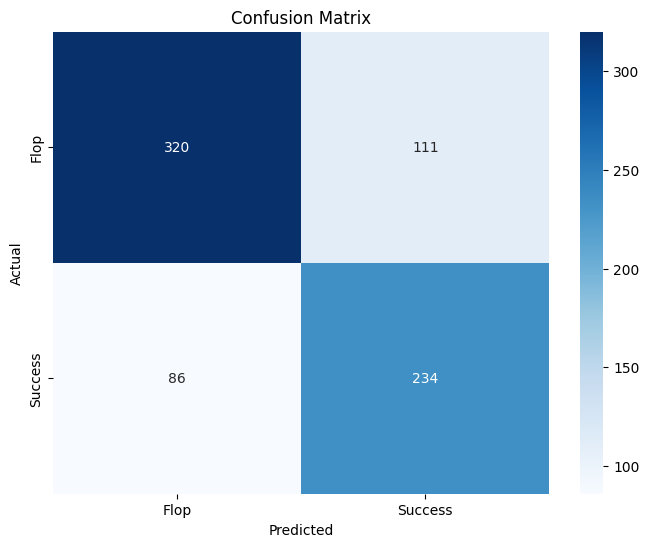

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Flop', 'Success'], yticklabels=['Flop', 'Success'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

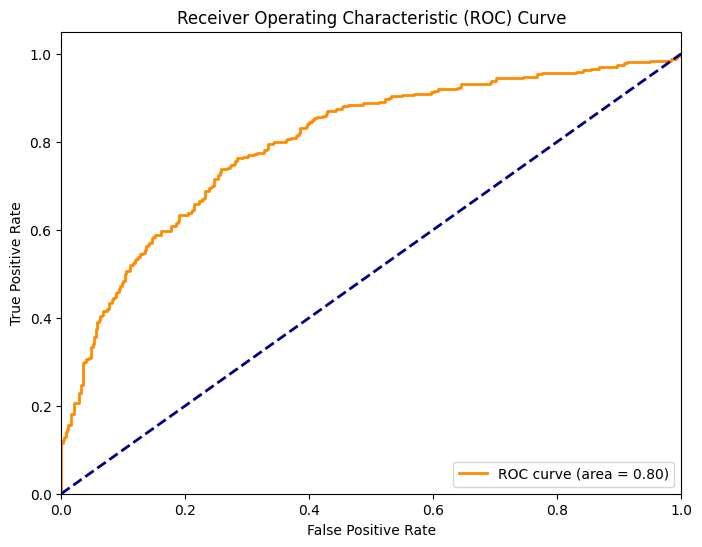

In [ ]:
# 2. ROC Curve
y_score = log_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

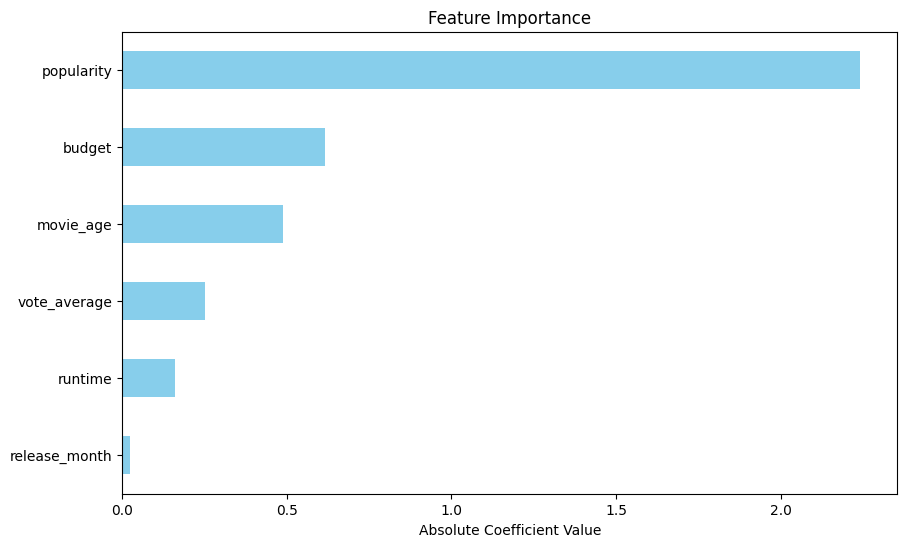

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Update importance plot for raw popularity
importances = np.abs(log_model.coef_[0])
feat_importances = pd.Series(importances, index=X.columns)

plt.figure(figsize=(10, 6))
feat_importances.sort_values().plot(kind='barh', color='skyblue')
plt.title("Feature Importance")
plt.xlabel("Absolute Coefficient Value")
plt.show()

In [ ]:
print("Columns currently in X (model features):")
display(X.columns.tolist())

print("\nIs 'revenue' in X?")
print('revenue' in X.columns)

Columns currently in X (model features):


['budget',
 'popularity',
 'runtime',
 'vote_average',
 'release_month',
 'movie_age']


Is 'revenue' in X?
False


### 9. Inference Function
A utility function to predict the success of new movie parameters using the trained pipeline.

In [ ]:
def test_new_movie():
    print("--- Movie Success Predictor ---")
    try:
        budget = float(input("Enter Budget (e.g., 50000000): "))
        popularity = float(input("Enter Popularity Score (e.g., 30.5): "))
        runtime = float(input("Enter Runtime in minutes (e.g., 120): "))
        vote_avg = float(input("Enter Expected Vote Average (1.0 - 10.0): "))
        month = int(input("Enter Release Month (1-12): "))
        age = int(input("Enter Movie Age (years since release): "))

        predict_movie_success(budget, runtime, vote_avg, popularity, month, age)
    except ValueError:
        print("Invalid input. Please enter numbers only.")

# Run the function to start testing
test_new_movie()

--- Movie Success Predictor ---
Enter Budget (e.g., 50000000): 237000000
Enter Popularity Score (e.g., 30.5): 92
Enter Runtime in minutes (e.g., 120): 161
Enter Expected Vote Average (1.0 - 10.0): 7.8
Enter Release Month (1-12): 12
Enter Movie Age (years since release): 17

--- Prediction Result ---
Predicted Status: SUCCESS
Probability of Success: 83.82%


In [ ]:
def test_new_movie():
    print("--- Movie Success Predictor ---")
    try:
        budget = float(input("Enter Budget (e.g., 50000000): "))
        popularity = float(input("Enter Popularity Score (e.g., 30.5): "))
        runtime = float(input("Enter Runtime in minutes (e.g., 120): "))
        vote_avg = float(input("Enter Expected Vote Average (1.0 - 10.0): "))
        month = int(input("Enter Release Month (1-12): "))
        age = int(input("Enter Movie Age (years since release): "))

        predict_movie_success(budget, runtime, vote_avg, popularity, month, age)
    except ValueError:
        print("Invalid input. Please enter numbers only.")

# Run the function to start testing
test_new_movie()

--- Movie Success Predictor ---
Enter Budget (e.g., 50000000): 600000000
Enter Popularity Score (e.g., 30.5): 66
Enter Runtime in minutes (e.g., 120): 146
Enter Expected Vote Average (1.0 - 10.0): 6.8
Enter Release Month (1-12): 8
Enter Movie Age (years since release): 1

--- Prediction Result ---
Predicted Status: FLOP
Probability of Success: 0.23%
